# What the enforced feature-norm bound costs on Criteo

Private SpiderBoost has no clipping line, so nothing at runtime makes its
sensitivity bound true. ADR-0009 left `L0` as an unchecked caller claim and
recorded the dilemma: a defensible constant on a heavy-tailed feature set is
*either* fitted on the data — an access no budget accounts for — *or* large
enough to drown the signal.

ADR-0012 closed the first horn. `L0` is no longer estimated: a per-record map
rescales every row to `l2` norm at most `R`, reading no aggregate and costing
no budget, and `accounting.lipschitz` turns `R` and a bias flag into
`(L0, L1, eta)` with no data argument at all. Nothing here reopens that. This
notebook measures the **second** horn, which ADR-0012 did not close and
changed the shape of: `R` is now free, so the question is no longer whether the
data forces `L0` up, but whether any `R` leaves Criteo's signal standing once
the noise that `R` implies is added.

Two costs move in opposite directions, and both are visible below.

- **`R` too large.** Above the data's own norms the cap binds on nothing, so
  the features are unchanged while `L0 = sqrt(R^2 + 1)` grows and Theorem
  B.3's step size `eta = 1/(2 L1) = 2/L0^2` shrinks. One step moves the
  parameters by `eta * ||g||` and is displaced by `eta * mu * L0 / b` per
  coordinate, so signal falls like `1/R^2` and noise only like `1/R`.
- **`R` too small.** The cap saturates every row, the feature block has norm
  exactly `R`, and the gradient signal in it scales like `R` — but the
  augmented norm is `sqrt(R^2 + 1)`, floored at 1 by the bias coordinate. Below
  `R = 1` the noise stops falling and the signal does not.

So there should be an interior optimum, sitting where `R` meets this dataset's
norm scale. That is a fact about Criteo rather than about the algorithm, which
is why it is measured here and not read out of a paper.

**What this notebook may not do, and does not.** ADR-0012 forbids choosing `R`
by reading the data's norm distribution: an `R` arrived at that way is a fitted
`L0`, no more honest for being generous. The grid below is fixed before
anything loads — a log grid from 0.25 to 16, straddling both the 1 the bias
coordinate puts a floor at and the ~16.7 ADR-0013 already records as this
file's largest standardized row norm — and nothing here computes a norm, a
maximum or a quantile of the features. What it computes is **utility at each
of those `R`**, which is an experiment, not a routine that derives a constant.

That distinction does not make the output free to use. Any `R` carried out of
here into a reported epsilon inherits ADR-0012's provenance obligation: this
is a non-private exploratory run, its own epsilon is invalid, and that has to
be said beside the number rather than left to be inferred.


In [1]:
import time

import jax
import matplotlib.pyplot as plt
import numpy as np

from dimma.accounting.lipschitz import logreg_bce_constants
from dimma.accounting.spiderboost import epsilon as spiderboost_epsilon
from dimma.accounting.spiderboost import noise_scales
from dimma.algorithms.sgd import train as sgd
from dimma.algorithms.spiderboost import train as spiderboost
from dimma.core import updates
from dimma.datasets.criteo import load_criteo
from dimma.metrics.decomposition import log_loss_decomposition
from dimma.metrics.scoring import log_loss, normalized_entropy
from dimma.models.logreg import forward, init_params
from dimma.models.losses import per_sample_bce_loss

DEVICE = "gpu" if any(d.platform == "gpu" for d in jax.devices()) else "cpu"
print(f"jax devices: {jax.devices()}  ->  DEVICE = {DEVICE!r}")

# Figure palette. Blue carries the private arm, orange the same run with the
# noise switched off; the two reference levels are drawn in grey because they
# are the frame rather than a third and fourth series.
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e1e0d9"
PRIVATE_C, CONTROL_C = "#2a78d6", "#eb6834"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": MUTED,
    "axes.titlecolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "lines.linewidth": 2.0, "lines.markersize": 6.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "font.size": 10,
})


jax devices: [CudaDevice(id=0)]  ->  DEVICE = 'gpu'


## 1. The protocol, fixed before anything ran

Every row of every table below is the same run with one thing changed. The
budget, the step count, the schedule and the two batch sizes are held; `R`
moves, and with it the three quantities `R` implies.

`R` is the only axis because it is the only one under test. A learning-rate
sweep would be meaningless here: Theorem B.3 *fixes* `eta = 1/(2 L1)`, so the
step size is not a hyperparameter of this algorithm — it is a consequence of
`R`, and departing from it drops the convergence guarantee while leaving the
privacy intact.


In [2]:
TARGET_EPSILON = 3.0
TARGET_DELTA = 1e-6
STEPS = 10_000

# Algorithm 2's schedule. One anchor release every 50 steps, so 200 of them
# and 9,800 variation releases, composed as two subsampled Gaussians.
ANCHOR_INTERVAL = 50
B1 = 8192      # anchor branch, Algorithm 2's b_1
B2 = 1024      # variation branch, b_2

# Fixed a priori. A log grid straddling 1, which is where the bias
# coordinate's contribution to the augmented norm puts a floor, carried up to
# 16 so that it also straddles the ~16.7 ADR-0013 already records as the
# largest standardized row norm. Nothing here reads the data to pick it.
R_GRID = [0.25, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0]

# `dimma.models.logreg` carries a bias, which augments the feature vector
# with a constant 1. Worth a factor of two in L1 at R = 1, and a wrong one
# reports an epsilon that is simply false — ADR-0012.
HAS_BIAS = True
N_BINS = 15
INIT_SEED = 0
BASE_SEED = 20260816

print(f"epsilon = {TARGET_EPSILON} at delta = {TARGET_DELTA}, "
      f"{STEPS:,} steps, anchor every {ANCHOR_INTERVAL}")
print(f"R grid: {R_GRID}")


epsilon = 3.0 at delta = 1e-06, 10,000 steps, anchor every 50
R grid: [0.25, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0]


## 2. Where `R` enters, before any data is loaded

`logreg_bce_constants` takes `R` and a bias flag and returns the triple
together, because Theorem B.3 welds them: `L0 = sqrt(R^2 + 1)`,
`L1 = L0^2 / 4`, `eta = 1/(2 L1)`. This cell touches no array. It is the whole
of what `R` does to the guarantee, and it is why the same `R` cannot be argued
about twice.

Read the last column against the second. Across the grid `L0` grows by a
factor of about 15 and the noise per released coordinate grows with it,
linearly; the step size falls by a factor of about 242, quadratically, because
`eta = 2/L0^2`. That asymmetry is the "`R` too large" arm of the trade, and it
is arithmetic rather than measurement — it is true before any data is seen.
What measurement has to settle is where it starts binding, which is the other
arm's business.


In [3]:
print(f"{'R':>6} {'L0':>8} {'L1':>9} {'eta':>10} {'noise/coord':>12}")
for bound in R_GRID:
    c = logreg_bce_constants(bound, has_bias=HAS_BIAS)
    # The anchor branch's standard deviation per released coordinate, at a
    # unit multiplier: what a step's noise is proportional to.
    print(f"{bound:>6} {c.lipschitz_constant:8.4f} "
          f"{c.smoothness_constant:9.4f} {c.step_size:10.4f} "
          f"{c.lipschitz_constant / B1:12.3e}")


     R       L0        L1        eta  noise/coord
  0.25   1.0308    0.2656     1.8824    1.258e-04
   0.5   1.1180    0.3125     1.6000    1.365e-04
   1.0   1.4142    0.5000     1.0000    1.726e-04
   2.0   2.2361    1.2500     0.4000    2.730e-04
   4.0   4.1231    4.2500     0.1176    5.033e-04
   8.0   8.0623   16.2500     0.0308    9.842e-04
  16.0  16.0312   64.2500     0.0078    1.957e-03


## 3. What one run is scored on

Threshold-free scores first, from `dimma.metrics`: log loss is the objective
the loop descends, and normalized entropy states the constant predictor as
1.0. Beside them the **log-loss decomposition**, which is what this notebook
actually turns on.

*Drowning the signal* is a claim about **resolution** — how far the bins pull
apart from the base rate — and not about calibration. Under equal-mass binning
resolution is exactly the part a ranking score can see, and calibration
carries everything a ranking score is invariant to, so the two terms land on
"what PR-AUC measures" and "what PR-AUC cannot". A private arm that loses
resolution has lost the signal; one that only gains calibration has kept it
and is stating it wrongly, which is a different failure with a different fix.

PR-AUC is reported alongside because it is the CTR-benchmark convention and
because it is the number a reader of #11 will look for. It is not the number
selection is done on. ROC-AUC appears nowhere: at a 25% base rate it is
flattering and reads well for a model that has learned nothing.

**The operating point.** A confusion matrix needs one and `p > 0.5` is the
wrong one — at this base rate a calibrated model rarely emits it at all, so
that threshold reports the base rate rather than the classifier. The threshold
is the **training-split base rate**, fixed before any run, identical for every
row, and a training-split statistic, so it falls under the caveat ADR-0008
already records rather than adding a read of the test labels.


In [4]:
def average_precision(probs, labels):
    """Area under the precision-recall curve: sort descending, integrate.

    Local by decision, not omission: `dimma.metrics` holds nothing that
    needs an operating point, and a ranking score is a proxy for one term
    of the decomposition next to it.
    """
    order = np.argsort(-probs)
    hits = labels[order]
    precision = np.cumsum(hits) / np.arange(1, len(hits) + 1)
    return float((precision * hits).sum() / hits.sum())


def confusion_at(probs, labels, threshold):
    """(tn, fp, fn, tp) for `call it a click when p >= threshold`."""
    pred = probs >= threshold
    truth = labels > 0.5
    return (int((~pred & ~truth).sum()), int((pred & ~truth).sum()),
            int((~pred & truth).sum()), int((pred & truth).sum()))


def evaluate(probs, labels, threshold):
    """Every number one arm is read on, from one array of probabilities."""
    tn, fp, fn, tp = confusion_at(probs, labels, threshold)
    parts = log_loss_decomposition(probs, labels, n_bins=N_BINS)
    return dict(
        loss=log_loss(probs, labels),
        ne=normalized_entropy(probs, labels),
        pr_auc=average_precision(probs, labels),
        resolution=float(parts.resolution),
        calibration=float(parts.calibration),
        precision=tp / (tp + fp) if tp + fp else float("nan"),
        recall=tp / (tp + fn) if tp + fn else float("nan"),
        confusion=(tn, fp, fn, tp),
    )


def probabilities(params, x):
    """`forward` is a single-example function; squash once, score off it."""
    logits = jax.vmap(forward, in_axes=(None, 0))(params, x)
    return np.asarray(jax.nn.sigmoid(logits), dtype=np.float64)


COLUMNS = (f"{'log-loss':>9} {'NE':>7} {'PR-AUC':>7} {'resol':>7} "
           f"{'calib':>7} {'prec':>6} {'recall':>7}")


def row(label, result, width=22):
    return (f"{label:<{width}}{result['loss']:9.4f} {result['ne']:7.4f} "
            f"{result['pr_auc']:7.4f} {result['resolution']:7.4f} "
            f"{result['calibration']:7.4f} {result['precision']:6.3f} "
            f"{result['recall']:7.3f}")


def show_confusion(confusion, title):
    tn, fp, fn, tp = confusion
    print(f"{title}\n{'':>12}{'pred 0':>10}{'pred 1':>10}")
    print(f"{'true 0':>12}{tn:>10,}{fp:>10,}")
    print(f"{'true 1':>12}{fn:>10,}{tp:>10,}")


## 4. One `R`, both arms

`fit` runs Algorithm 2 at the constants `R` implies. The **control** is the
identical run with the three noise scales at `1e-12` — same `R`, same capped
data, same step size, same sampling. That is what separates the two costs:
the gap from the control to the uncapped ceiling is what the **cap** took, and
the gap from the private arm to the control is what the **noise** took.

The control is not a baseline in ADR-0005's sense. It is the same loop with
one term switched off, and it spends no meaningful epsilon; the real baseline
is plain SGD, which appears once at the end as the ceiling.


In [5]:
def sweep_one(bound, split, y_test, threshold, start):
    """Both arms at one `R`, plus the scales and the epsilon they cost."""
    n_train = split.x_train.shape[0]
    constants = logreg_bce_constants(bound, has_bias=HAS_BIAS)
    scales = noise_scales(
        lipschitz_constant=constants.lipschitz_constant,
        smoothness_constant=constants.smoothness_constant,
        target_epsilon=TARGET_EPSILON, target_delta=TARGET_DELTA,
        steps=STEPS, anchor_interval=ANCHOR_INTERVAL,
        anchor_expected_batch_size=B1, variation_expected_batch_size=B2,
        dataset_size=n_train,
    )
    spent = spiderboost_epsilon(
        lipschitz_constant=constants.lipschitz_constant,
        smoothness_constant=constants.smoothness_constant,
        **scales._asdict(), target_delta=TARGET_DELTA, steps=STEPS,
        anchor_interval=ANCHOR_INTERVAL, anchor_expected_batch_size=B1,
        variation_expected_batch_size=B2, dataset_size=n_train,
    )
    assert spent <= TARGET_EPSILON + 1e-9

    def fit(three, index):
        output, _ = spiderboost.train(
            per_sample_bce_loss, start, updates.sgd(constants.step_size),
            split.x_train, split.y_train,
            jax.random.key(BASE_SEED + index),
            np.random.default_rng([BASE_SEED, index]),
            steps=STEPS, anchor_interval=ANCHOR_INTERVAL,
            anchor_expected_batch_size=B1, variation_expected_batch_size=B2,
            **three,
        )
        return evaluate(probabilities(output, split.x_test), y_test, threshold)

    off = dict.fromkeys(scales._asdict(), 1e-12)
    return dict(R=bound, constants=constants, epsilon=spent,
                private=fit(scales._asdict(), 0), control=fit(off, 1))


## 5. The default chain

`standardize=False`, which is ADR-0013's default and the cheap chain: the
integer block arrives already inside `[0, 1]` and `log1p` compresses it
further, so row norms stay small and an `R` near 1 is not obviously absurd.
Section 6 pays ADR-0013's price and runs the same grid standardized.

All 39 features, the full file, the split seed fixed at 0. Each `R` reloads,
because the cap goes last in the loader's chain and after every fitted map —
applying it any earlier would bound nothing afterwards.


In [6]:
def run_grid(standardize):
    """The whole grid on one chain, plus the floor and the ceiling."""
    results, t0 = [], time.time()
    for bound in R_GRID:
        split = load_criteo(features="all", preprocess=True,
                            standardize=standardize, download=False, seed=0,
                            device=DEVICE, feature_norm_bound=bound)
        y_test = np.asarray(split.y_test, dtype=np.float64)
        threshold = float(split.y_train.mean())
        start = init_params(jax.random.key(INIT_SEED), split.x_train.shape[1])
        results.append(sweep_one(bound, split, y_test, threshold, start))
        print(f"  R = {bound} done  ({time.time() - t0:.0f}s)")

    # The two reference levels, on the same chain with no cap and so no
    # constants implied and no epsilon claimed.
    split = load_criteo(features="all", preprocess=True,
                        standardize=standardize, download=False, seed=0,
                        device=DEVICE, feature_norm_bound=None)
    y_test = np.asarray(split.y_test, dtype=np.float64)
    threshold = float(split.y_train.mean())
    start = init_params(jax.random.key(INIT_SEED), split.x_train.shape[1])

    ceiling = evaluate(probabilities(sgd.train(
        per_sample_bce_loss, start, updates.sgd(0.3),
        split.x_train, split.y_train,
        np.random.default_rng([BASE_SEED, 999]),
        steps=STEPS, batch_size=1024,
    ), split.x_test), y_test, threshold)

    constant = evaluate(np.full_like(y_test, threshold), y_test, threshold)
    # Its PR-AUC is entered as the base rate rather than computed: every
    # score is identical, so an average precision over them would be
    # reporting the order the rows arrived in. Its resolution the
    # decomposition already returns as exactly zero.
    constant["pr_auc"] = float(y_test.mean())
    print(f"total {time.time() - t0:.0f}s on {DEVICE}")
    return results, ceiling, constant, threshold


plain, plain_ceiling, plain_constant, plain_threshold = run_grid(False)


criteo: 39 features. I1-I13: NaN filled with the train-split median, clipped below at 0, log1p — the fill and the clip are no-ops on stored values that carry neither NaN nor negatives, and log1p acts on [0, 1]. C1-C26: each category ID replaced by that category's relative frequency in the train split, with categories unseen in training encoded as 0.0. Not standardized: the columns keep the scales above, and no mean or standard deviation was fitted. Every row then rescaled to l2 norm at most 0.25, one record at a time.
E0816 20:39:32.982756  912309 cuda_executor.cc:1176] [0] Failed to allocate device memory of 35.53GiB (38145097728 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
=== Source Location Trace: ===
external/xla/xla/stream_executor/cuda/cuda_status.cc:45
external/xla/xla/stream_executor/cuda/cuda_device_allocator.cc:226
external/xla/xla/stream_executor/cuda/cuda_device_allocator.cc:403

E0816 20:39:32.982895  912309 cuda_executor.cc:1176] [0] Failed to al

  R = 0.25 done  (82s)


criteo: 39 features. I1-I13: NaN filled with the train-split median, clipped below at 0, log1p — the fill and the clip are no-ops on stored values that carry neither NaN nor negatives, and log1p acts on [0, 1]. C1-C26: each category ID replaced by that category's relative frequency in the train split, with categories unseen in training encoded as 0.0. Not standardized: the columns keep the scales above, and no mean or standard deviation was fitted. Every row then rescaled to l2 norm at most 0.5, one record at a time.


  R = 0.5 done  (163s)


criteo: 39 features. I1-I13: NaN filled with the train-split median, clipped below at 0, log1p — the fill and the clip are no-ops on stored values that carry neither NaN nor negatives, and log1p acts on [0, 1]. C1-C26: each category ID replaced by that category's relative frequency in the train split, with categories unseen in training encoded as 0.0. Not standardized: the columns keep the scales above, and no mean or standard deviation was fitted. Every row then rescaled to l2 norm at most 1.0, one record at a time.


...

  R = 8.0 done  (477s)


criteo: 39 features. I1-I13: NaN filled with the train-split median, clipped below at 0, log1p — the fill and the clip are no-ops on stored values that carry neither NaN nor negatives, and log1p acts on [0, 1]. C1-C26: each category ID replaced by that category's relative frequency in the train split, with categories unseen in training encoded as 0.0. Not standardized: the columns keep the scales above, and no mean or standard deviation was fitted. Every row then rescaled to l2 norm at most 16.0, one record at a time.


  R = 16.0 done  (555s)


criteo: 39 features. I1-I13: NaN filled with the train-split median, clipped below at 0, log1p — the fill and the clip are no-ops on stored values that carry neither NaN nor negatives, and log1p acts on [0, 1]. C1-C26: each category ID replaced by that category's relative frequency in the train split, with categories unseen in training encoded as 0.0. Not standardized: the columns keep the scales above, and no mean or standard deviation was fitted.


total 570s on gpu


In [7]:
print(f"decision threshold p >= {plain_threshold:.4f} "
      f"(the training-split base rate)\n")
print(f"{'':<22}{COLUMNS}")
print(row("constant predictor", plain_constant))
for result in plain:
    print(row(f"R = {result['R']}, eps = {result['epsilon']:.2f}",
              result["private"]))
    print(row("    same R, no noise", result["control"]))
print(row("uncapped plain SGD", plain_ceiling))


decision threshold p >= 0.2510 (the training-split base rate)

                       log-loss      NE  PR-AUC   resol   calib   prec  recall
constant predictor       0.5645  1.0000  0.2520  0.0000  0.0000  0.252   1.000
R = 0.25, eps = 3.00     0.5476  0.9701  0.4116  0.0410  0.0243  0.369   0.661
    same R, no noise     0.5264  0.9324  0.4210  0.0449  0.0070  0.374   0.674
R = 0.5, eps = 3.00      0.5300  0.9388  0.4180  0.0437  0.0095  0.378   0.653
    same R, no noise     0.5180  0.9176  0.4274  0.0474  0.0010  0.383   0.658
R = 1.0, eps = 3.00      0.5207  0.9224  0.4237  0.0462  0.0026  0.385   0.644
    same R, no noise     0.5162  0.9144  0.4317  0.0489  0.0006  0.385   0.658
R = 2.0, eps = 3.00      0.5199  0.9209  0.4260  0.0462  0.0019  0.384   0.647
    same R, no noise     0.5160  0.9140  0.4342  0.0493  0.0007  0.383   0.665
R = 4.0, eps = 3.00      0.5319  0.9422  0.4134  0.0407  0.0084  0.371   0.647
    same R, no noise     0.5188  0.9189  0.4287  0.0470  0.0015  0.3

### Reading the grid

**Every row clears the constant predictor**, at every `R` in the grid, which
is the first thing to check and is not a given — it is the outcome ADR-0009
warned might not arrive. The floor is `NE = 1.0` and `resolution = 0`, and the
worst private row on the grid still sits at `NE = 0.970` with four fifths of
the uncapped ceiling's resolution standing.

**The interior optimum is where the arithmetic said it would be.** Private
resolution runs 0.0410, 0.0437, 0.0462, 0.0462, 0.0407, 0.0201, 0.0016 across
the grid: a flat top over `R` in `[1, 2]` and a fall on both sides, for two
unrelated reasons. On the left the cap saturates nearly every row while the
augmented norm is floored at 1 by the bias. On the right the cap binds on
nothing, so a larger `R` buys no fidelity and only shrinks `eta`
quadratically. The right-hand fall is the steeper of the two by a long way: by
`R = 16` the private run is at `NE = 0.9993` and PR-AUC 0.2635 against a floor
of 0.2520 — it has learned essentially nothing, which is the failure ADR-0009
described, reached from the direction ADR-0012 left open.

**Neither cost dominates at the optimum, and both are small.** Against the
uncapped ceiling's 0.4410 PR-AUC, `R = 2` gives up 0.0068 to the cap and a
further 0.0082 to the noise — together 3.4%. Away from the optimum one or the
other takes over: at `R = 0.25` the cap alone costs 0.0200 and the noise
0.0094; at `R = 16` the cap-and-step-size arm costs 0.0708 and the noise a
further 0.1067.

**Where the noise actually lands is calibration, not order.** At `R = 0.25` the
private run's calibration term is 0.0243 against the control's 0.0070, a
gap of nearly tenfold, while its resolution is within 10% of the control's.
At `R = 1` the same pair is 0.0026 against 0.0006. So the small-`R` failure is
not that the model stops telling records apart — it is that it states
probabilities the observed rates do not match, which is what a ranking score
is invariant to and would have missed entirely.

**`R = 1` is inside the flat top.** That is the result that matters for the
provenance question, because `R = 1` is the DP-ERM line's standing premise and
needs no look at this data. `R = 2` scores a little better and is not
available on the same terms — nothing outside this notebook justifies it.


In [8]:
best = max(plain, key=lambda r: r["private"]["resolution"])
print(f"most resolution at R = {best['R']}, "
      f"epsilon = {best['epsilon']:.3f}, delta = {TARGET_DELTA}\n")
show_confusion(best["private"]["confusion"],
               f"Private SpiderBoost, R = {best['R']}, {STEPS:,} steps")
print()
show_confusion(plain_ceiling["confusion"], "uncapped plain SGD, no epsilon")
print()
show_confusion(plain_constant["confusion"],
               "the constant predictor, for scale")


most resolution at R = 2.0, epsilon = 3.000, delta = 1e-06

Private SpiderBoost, R = 2.0, 10,000 steps
                pred 0    pred 1
      true 0    97,394    52,206
      true 1    17,800    32,600

uncapped plain SGD, no epsilon
                pred 0    pred 1
      true 0    99,421    50,179
      true 1    18,045    32,355

the constant predictor, for scale
                pred 0    pred 1
      true 0         0   149,600
      true 1         0    50,400


### The two costs, drawn apart

Left, the proper score the loop descends; right, the resolution term — the
share of the base rate's uncertainty the model actually removed, and the one
"drowns the signal" is a claim about. Two scales, so two panels rather than
two axes on one plot.

The grey lines are the frame: the constant predictor is what learning nothing
scores, and uncapped plain SGD is what the same model reaches with no cap, no
noise and no epsilon at all. Between them, the orange curve is what the cap
alone left standing and the blue curve is what survived the noise on top.


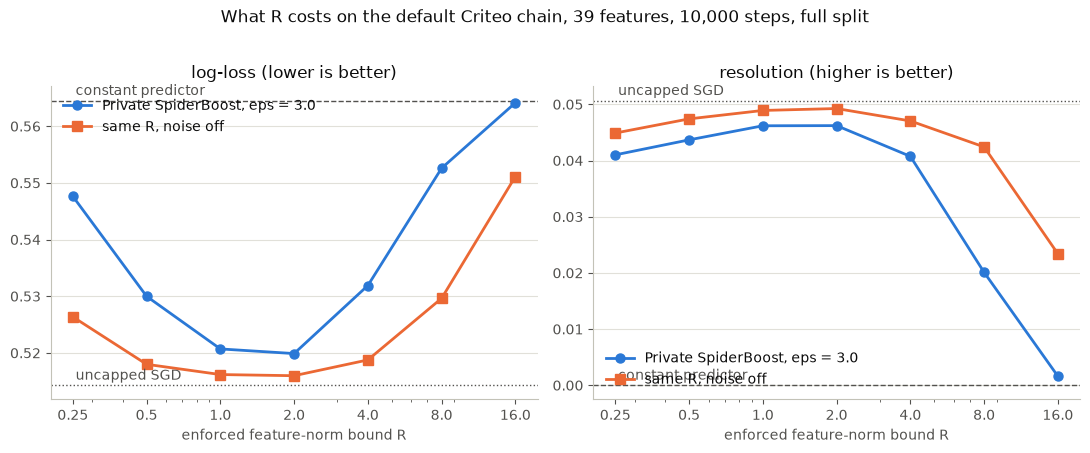

In [9]:
def panels(results, ceiling, constant, chain):
    """Log-loss and resolution against R, both arms, one chain.

    Two scales, so two panels rather than two axes on one plot. The grey
    lines are the frame: what learning nothing scores, and what the same
    model reaches with no cap, no noise and no epsilon.
    """
    grid = [r["R"] for r in results]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))

    for ax, key, name, corner in (
            (axes[0], "loss", "log-loss (lower is better)", "upper left"),
            (axes[1], "resolution", "resolution (higher is better)",
             "lower left"),
    ):
        ax.axhline(constant[key], color=MUTED, linestyle="--", linewidth=1)
        ax.axhline(ceiling[key], color=MUTED, linestyle=":", linewidth=1)
        ax.plot(grid, [r["private"][key] for r in results], marker="o",
                color=PRIVATE_C,
                label=f"Private SpiderBoost, eps = {TARGET_EPSILON}")
        ax.plot(grid, [r["control"][key] for r in results], marker="s",
                color=CONTROL_C, label="same R, noise off")
        ax.set_xscale("log")
        ax.set_xticks(grid)
        ax.set_xticklabels([str(g) for g in grid])
        ax.set_xlabel("enforced feature-norm bound R")
        ax.set_title(name)
        ax.grid(axis="y")
        ax.annotate("constant predictor", (grid[0], constant[key]),
                    textcoords="offset points", xytext=(2, 4), color=MUTED)
        ax.annotate("uncapped SGD", (grid[0], ceiling[key]),
                    textcoords="offset points", xytext=(2, 4), color=MUTED)
        ax.legend(loc=corner)

    fig.suptitle(f"What R costs on {chain}, 39 features, {STEPS:,} steps, "
                 f"full split", y=1.02)
    fig.tight_layout()
    plt.show()


panels(plain, plain_ceiling, plain_constant, "the default Criteo chain")


## 6. The standardized chain, for the price ADR-0013 named

ADR-0013 records that standardizing sets every column's scale to 1 and so puts
a typical row's norm near `sqrt(d)`: on this file the largest row norm over all
39 features goes from about 2.7 to about 16.7. It states the consequence
arithmetically — an `R` that leaves standardized Criteo intact is roughly seven
times one that leaves the default chain intact, so `L1` and the noise on the
variation step grow by a factor near fifty and the step size shrinks by the
same — and leaves the alternative, keeping `R` small and capping anyway, as
the thing that "discards most of each record".

Same grid, same budget, same everything else. This is the arithmetic being
paid.


In [10]:
std, std_ceiling, std_constant, std_threshold = run_grid(True)


criteo: 39 features. I1-I13: NaN filled with the train-split median, clipped below at 0, log1p — the fill and the clip are no-ops on stored values that carry neither NaN nor negatives, and log1p acts on [0, 1]. C1-C26: each category ID replaced by that category's relative frequency in the train split, with categories unseen in training encoded as 0.0. Every column then standardized by the train-split mean and standard deviation. Every row then rescaled to l2 norm at most 0.25, one record at a time.


  R = 0.25 done  (78s)


criteo: 39 features. I1-I13: NaN filled with the train-split median, clipped below at 0, log1p — the fill and the clip are no-ops on stored values that carry neither NaN nor negatives, and log1p acts on [0, 1]. C1-C26: each category ID replaced by that category's relative frequency in the train split, with categories unseen in training encoded as 0.0. Every column then standardized by the train-split mean and standard deviation. Every row then rescaled to l2 norm at most 0.5, one record at a time.


  R = 0.5 done  (157s)


criteo: 39 features. I1-I13: NaN filled with the train-split median, clipped below at 0, log1p — the fill and the clip are no-ops on stored values that carry neither NaN nor negatives, and log1p acts on [0, 1]. C1-C26: each category ID replaced by that category's relative frequency in the train split, with categories unseen in training encoded as 0.0. Every column then standardized by the train-split mean and standard deviation. Every row then rescaled to l2 norm at most 1.0, one record at a time.


...

  R = 8.0 done  (477s)


criteo: 39 features. I1-I13: NaN filled with the train-split median, clipped below at 0, log1p — the fill and the clip are no-ops on stored values that carry neither NaN nor negatives, and log1p acts on [0, 1]. C1-C26: each category ID replaced by that category's relative frequency in the train split, with categories unseen in training encoded as 0.0. Every column then standardized by the train-split mean and standard deviation. Every row then rescaled to l2 norm at most 16.0, one record at a time.


  R = 16.0 done  (556s)


criteo: 39 features. I1-I13: NaN filled with the train-split median, clipped below at 0, log1p — the fill and the clip are no-ops on stored values that carry neither NaN nor negatives, and log1p acts on [0, 1]. C1-C26: each category ID replaced by that category's relative frequency in the train split, with categories unseen in training encoded as 0.0. Every column then standardized by the train-split mean and standard deviation.


total 571s on gpu


In [11]:
print(f"decision threshold p >= {std_threshold:.4f}\n")
print(f"{'':<22}{COLUMNS}")
print(row("constant predictor", std_constant))
for result in std:
    print(row(f"R = {result['R']}, eps = {result['epsilon']:.2f}",
              result["private"]))
    print(row("    same R, no noise", result["control"]))
print(row("uncapped plain SGD", std_ceiling))


decision threshold p >= 0.2510

                       log-loss      NE  PR-AUC   resol   calib   prec  recall
constant predictor       0.5645  1.0000  0.2520  0.0000  0.0000  0.252   1.000
R = 0.25, eps = 3.00     0.5290  0.9371  0.4255  0.0461  0.0110  0.383   0.639
    same R, no noise     0.5155  0.9132  0.4338  0.0489  0.0004  0.386   0.652
R = 0.5, eps = 3.00      0.5168  0.9155  0.4311  0.0482  0.0010  0.390   0.634
    same R, no noise     0.5137  0.9099  0.4394  0.0505  0.0001  0.387   0.655
R = 1.0, eps = 3.00      0.5148  0.9118  0.4354  0.0494  0.0001  0.391   0.635
    same R, no noise     0.5131  0.9090  0.4422  0.0513  0.0002  0.386   0.658
R = 2.0, eps = 3.00      0.5143  0.9110  0.4371  0.0499  0.0001  0.392   0.633
    same R, no noise     0.5132  0.9091  0.4433  0.0516  0.0004  0.385   0.660
R = 4.0, eps = 3.00      0.5142  0.9108  0.4376  0.0500  0.0002  0.394   0.629
    same R, no noise     0.5132  0.9091  0.4435  0.0516  0.0004  0.387   0.655
R = 8.0, eps = 3.00 

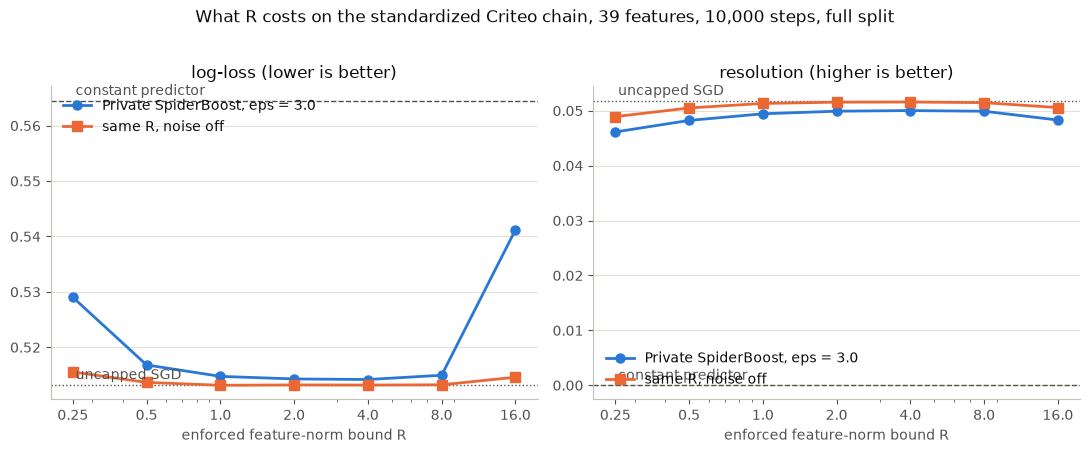

In [12]:
panels(std, std_ceiling, std_constant, "the standardized Criteo chain")


### ADR-0013's factor is confirmed. Its reason is not.

**The window moves, by about the factor ADR-0013 names.** Private resolution on
this chain runs 0.0461, 0.0482, 0.0494, 0.0499, 0.0500, 0.0499, 0.0483: a flat
top from `R = 2` to `R = 8` where the default chain's was `[1, 2]`. ADR-0013
predicted "roughly seven times" from the norms alone, and the optima move by
about four to seven. That much lands.

**What does not land is "either way standardization is paid for in the
budget".** At every `R` in the grid the standardized chain scores at least as
well as the default one, and at its own optimum it scores *better* — 0.4382
PR-AUC against 0.4260, and 0.0500 resolution against 0.0462. The fifty-fold
growth in `L1` is real and so is the fifty-fold shrink in `eta`, and the
measurement says they cancel rather than compound.

They cancel because `eta` and the noise scales are both fixed by `L0`, and the
cancellation is exact enough to write down. The variation branch's per-step
displacement is `eta * sigma_2 * ||w_t - w_{t-1}||`, and with
`sigma_2 = mu * L1 / b2` and `eta = 2 / L0^2` and `L1 = L0^2 / 4` that is
`mu * ||w_t - w_{t-1}|| / (2 * b2)` — with no `L0` in it at all. The anchor
branch's is `eta * sigma_1 = 2 * mu / (L0 * b1)`, which *falls* as `L0` grows.
So in parameter space a larger `R` does not add noise. Nor was epsilon ever
where it was paid, and the tables say so directly: every row of both spends
`eps = 3.00`, at seven different `L0`. That is the same independence DP-SGD's
epsilon has from its clipping norm, reappearing where ADR-0012's constants
replaced the clip. What ADR-0013 counted as a cost is a quantity that cancels
twice over.

**What actually collapses the run at large `R` is the signal, not the noise.**
The per-step signal is `eta * ||g|| = 2 * ||g|| / L0^2`, so the ratio that
matters is `||g|| / L0`. While the cap binds, `||g||` grows with `R` and the
ratio is flat — which is the whole flat top on both chains, and why the
standardized chain's top is wider rather than lower. Once the cap goes inert
`||g||` stops growing while `L0` does not, and the ratio falls like `1/R`.
That is the right-hand cliff, and it arrives on the default chain at `R = 4`
and on this one at `R = 16`, exactly where each chain's own norms run out.

**So ADR-0013's default survives its argument.** `standardize=False` is still
the right default and standardizing should still be asked for explicitly — the
fitted means and standard deviations are an unaccounted access to the training
split whatever they do to utility (ADR-0008), and part of the advantage above
is bought with that unpaid access. But the reason recorded in ADR-0013 — that
the wider `R` is paid for in noise — is not what happens, and a reader
choosing between the two chains on that basis would be choosing on a cost that
cancels. Flagged here rather than fixed: which reason ADR-0013 should record
is a decision, and it belongs to whoever designs #11 rather than to the
notebook that noticed it.


## 7. What this settles, and what it does not

**The `L0`-Lipschitz assumption is defensible on Criteo, and the `R` that makes
it true does not drown the signal.** Not at every `R` — at `R = 16` on the
default chain the private run is indistinguishable from a model with no
features — but over a window that is wide, that both chains have, and that on
the default chain contains `R = 1`. That last point is what makes the answer
usable rather than circular: `R = 1` is the DP-ERM line's standing premise,
fixed a priori, and it needs no look at this data. At `R = 1` and
`eps = 3, delta = 1e-6`, Private SpiderBoost keeps 91% of the uncapped
non-private model's resolution and 96% of its PR-AUC.

**The premise is now true by construction rather than assumed.** Nothing here
established that; ADR-0012 did, and `tests/integration/` pins it. What this
notebook adds is the other half — that paying for it is affordable on this
dataset — which is the half ADR-0009 said might not arrive.

**Three things this does not settle.**

- *Where `R` comes from, when it is not 1.* `R = 2` and `R = 8` score better on
  their respective chains and are not available on the same terms: nothing
  outside this notebook justifies them, and this notebook is a non-private
  exploratory run whose own epsilon is invalid. ADR-0012 puts that obligation
  on whoever reports the number and gives the library no way to record it.
- *One seed, no repeats.* Every row is a single run from a single
  initialization. The spread across the flat top is a few thousandths of
  PR-AUC, which is the same order as the CTR-benchmark significance threshold
  of 0.001 absolute, so the ordering *within* the flat top is not resolved
  here and should not be read as one. The cliffs are an order of magnitude
  larger and are not in doubt.
- *This schedule and this budget.* The calibrated multiplier is about 0.815:
  at `eps = 3`, `delta = 1e-6`, `n = 800,000` and these two sampling rates, the
  noise is mild. A tighter budget or a longer run moves the whole picture, and
  the flat top being flat is not a promise that it stays flat at `eps = 0.5`.

**The remaining looseness ADR-0012 names is not measured here and is real.**
`L0` is attained only as the logit diverges and `L1`'s `1/4` only at a logit of
zero, so both are worst-case constants a trained model never approaches; a
DP-SGD run whose clipping norm is tuned to the gradients it actually sees is
calibrating against a smaller sensitivity for the same budget. That is the
price of Algorithm 2 having no clipping line, ADR-0009 accepted it knowingly,
and what it is worth in utility is #11's comparison to make — not this
notebook's, which has only one algorithm in it.
